<h1 align="center">
B Term research notes
</h1>

1. A term recap .............................................................................................................................................................................................





# 1. Recap

In investigatng the connection between dynamical systems and MLPs the main use case of interest so far has been denoising Auto encoders applied to MNST images with gaussian noise applied. The larger topics covered so far in the resesarch of this MQP as well as relevant research from the Paffenroth research group includes:
1. RNNs are just discrete time dynamical systems and can be represented by a blockwise matrix of functions(Hershy et. al).
2. Technically all MLPs are discretions of Euler steps applied to a vector of n dimensions where n is the max width of the network layers.(MQP generated)
3. 

## MNIST Use Case
We start with the basic use case of applying denoising auto encoders to MNIST images with gaussian noise applied. This is a useful example to focus on because denosing pressents intuitively as an interative process. Imagine a denoising auto encoder that is good but not perfect. After being fed a "noisy" MNIST image of a 4, the output should look like a clearer image of the digit. In this case the DNAE takes in a noisy image and returns a less noisy one. The dynamical systems theory comes from taking the DNAEs output and feeding it back into the DNAE as input. Could it be the case that this would produce and even clearer image of the digit? 

### data prep


In [38]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms

transform = transforms.ToTensor()
train_data = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_data  = datasets.MNIST(root='./data', train=False, transform=transform, download=True)


We then wrap MNIST in a NoisyMNIST class so that every time we sample an image from the MNIST data set we get a clean noisy pair, with the noisy image generated at time we retrive the sample. We add pixel-wise random noise drawn from normal distribition with mean 0 and standard deviation sigma

In [39]:
class NoisyMNIST(Dataset):
    def __init__(self, mnist_dataset, noise_factor=0.01):
        self.mnist = mnist_dataset
        self.noise_factor = noise_factor

    def __len__(self):
        return len(self.mnist)
    
    def add_noise(self, img, sigma =.23):
        """
        Add zero-mean Gaussian noise to an MNIST image tensor in [0, 1].
        
        Args:
            img (torch.Tensor): Input image tensor, shape (C, H, W), values in [0, 1].
            sigma (float): Standard deviation of the Gaussian noise.
        
        Returns:
            torch.Tensor: Noisy image, same shape, clamped to [0, 1].
        """
        # Generate zero-mean Gaussian noise
        noise = torch.randn_like(img) * sigma
        
        # Add noise symmetrically (can brighten or darken)
        noisy = img + noise
        # Clamp to valid range
        noisy = torch.clamp(noisy, 0., 1.)
        return noisy
    

    def __getitem__(self, idx):
        # y = clean image (target)
        y, label = self.mnist[idx]
        # x = noisy image (input)
        x = self.add_noise(y, sigma=self.noise_factor)
        return x, y  # return noisy-clean pair

We will set up dataloaders for the training and testing data respectively. Here we render one sample for a sainity check that the nois is being applied correctly.

torch.Size([128, 1, 28, 28]) torch.Size([128, 1, 28, 28])


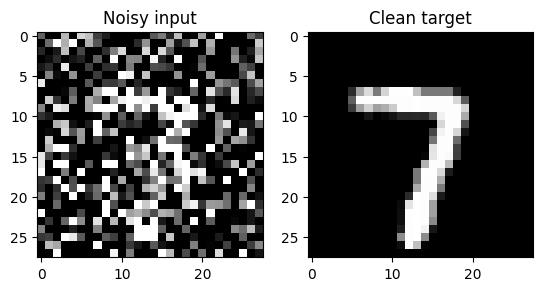

In [60]:
batch_size = 128

train_loader = DataLoader(
    NoisyMNIST(train_data, noise_factor=0.65),
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    NoisyMNIST(test_data, noise_factor=0.65),
    batch_size=batch_size,
    shuffle=False
)

x, y = next(iter(train_loader))
print(x.shape, y.shape)
# -> torch.Size([128, 1, 28, 28]) torch.Size([128, 1, 28, 28])

import matplotlib.pyplot as plt
plt.subplot(1,2,1)
plt.title("Noisy input")
plt.imshow(x[0][0].detach().cpu(), cmap="gray")
plt.subplot(1,2,2)
plt.title("Clean target")
plt.imshow(y[0][0].detach().cpu(), cmap="gray")
plt.show()

## Baseline DNAE Performace
While our goal is to apply, understand, and potentially iterative denoising to these images, we first must get a frame of reference. 
In order to do so we will construct a traditional DNAE and see it's general performance on this task, without doing any special dynamical systems tricks.


In [61]:
import torch.nn as nn
import numpy as np
class DAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512), nn.ReLU(),
            nn.Linear(512, 128), nn.ReLU(),
            nn.Linear(128, 64)
        )
        self.decoder = nn.Sequential(
            nn.Linear(64, 128), nn.ReLU(),
            nn.Linear(128, 512), nn.ReLU(),
            nn.Linear(512, 784), nn.Sigmoid(),
            nn.Unflatten(1, (1, 28, 28))
        )
    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

Using device: mps
Epoch [1/10]  Train Loss: 0.0606  Val Loss: 0.0410
Epoch [2/10]  Train Loss: 0.0363  Val Loss: 0.0319
Epoch [3/10]  Train Loss: 0.0305  Val Loss: 0.0283
Epoch [4/10]  Train Loss: 0.0275  Val Loss: 0.0259
Epoch [5/10]  Train Loss: 0.0254  Val Loss: 0.0242
Epoch [6/10]  Train Loss: 0.0239  Val Loss: 0.0230
Epoch [7/10]  Train Loss: 0.0228  Val Loss: 0.0221
Epoch [8/10]  Train Loss: 0.0219  Val Loss: 0.0212
Epoch [9/10]  Train Loss: 0.0213  Val Loss: 0.0207
Epoch [10/10]  Train Loss: 0.0207  Val Loss: 0.0202


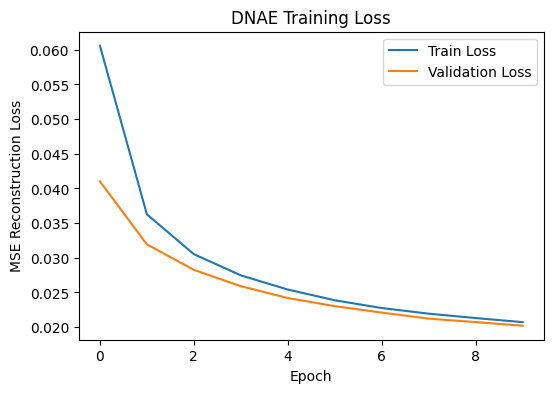

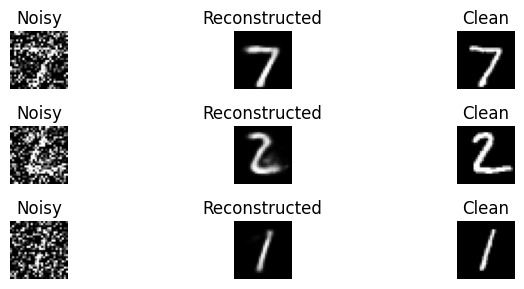

In [63]:
# --------------------------
# Training setup
# --------------------------
if torch.backends.mps.is_available() and torch.backends.mps.is_built():
    device = torch.device("mps")          # Apple GPU
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)
model = DAE().to(device)

criterion = nn.MSELoss()  # reconstruction loss
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Optional quick logic to set #epochs adaptively:
# (fewer if small dataset or on CPU)
if device.type == "cuda":
    num_epochs = 10
else:
    num_epochs = 10

train_losses = []
val_losses = []

# --------------------------
# Training loop
# --------------------------
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for x_noisy, x_clean in train_loader:
        x_noisy, x_clean = x_noisy.to(device), x_clean.to(device)

        optimizer.zero_grad()
        outputs = model(x_noisy)
        loss = criterion(outputs, x_clean)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x_noisy.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    # Validation loop
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x_noisy, x_clean in test_loader:
            x_noisy, x_clean = x_noisy.to(device), x_clean.to(device)
            outputs = model(x_noisy)
            loss = criterion(outputs, x_clean)
            val_loss += loss.item() * x_noisy.size(0)

    val_loss /= len(test_loader.dataset)
    val_losses.append(val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}]  Train Loss: {epoch_loss:.4f}  Val Loss: {val_loss:.4f}")

    # Early stopping logic (quick and simple):
    if epoch > 1 and abs(val_losses[-1] - val_losses[-2]) < 1e-5:
        print("Validation loss plateaued — stopping early.")
        break

# --------------------------
# Plot reconstruction loss
# --------------------------
plt.figure(figsize=(6,4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Reconstruction Loss")
plt.title("DNAE Training Loss")
plt.legend()
plt.show()

# --------------------------
# Visualize reconstruction on test set
# --------------------------
model.eval()
x_noisy, x_clean = next(iter(test_loader))
x_noisy, x_clean = x_noisy.to(device), x_clean.to(device)
with torch.no_grad():
    recon = model(x_noisy)

plt.figure(figsize=(8,3))
for i in range(3):
    plt.subplot(3,3,3*i+1)
    plt.imshow(x_noisy[i][0].cpu(), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

    plt.subplot(3,3,3*i+2)
    plt.imshow(recon[i][0].cpu(), cmap="gray")
    plt.title("Reconstructed")
    plt.axis("off")

    plt.subplot(3,3,3*i+3)
    plt.imshow(x_clean[i][0].cpu(), cmap="gray")
    plt.title("Clean")
    plt.axis("off")

plt.tight_layout()
plt.show()

## crippled version

Even with large amounts of noise applied this architecture eliminates almost all noise after a single pass. In order to investigate the efficacy of stacking, we will impliment a weaker model such that some non-trivial amount of noise remains after a single pass.

Using device: mps
Epoch [1/10]  Train Loss: 0.0657  Val Loss: 0.0522
Epoch [2/10]  Train Loss: 0.0433  Val Loss: 0.0370
Epoch [3/10]  Train Loss: 0.0353  Val Loss: 0.0330
Epoch [4/10]  Train Loss: 0.0322  Val Loss: 0.0306
Epoch [5/10]  Train Loss: 0.0300  Val Loss: 0.0289
Epoch [6/10]  Train Loss: 0.0287  Val Loss: 0.0276
Epoch [7/10]  Train Loss: 0.0276  Val Loss: 0.0266
Epoch [8/10]  Train Loss: 0.0268  Val Loss: 0.0259
Epoch [9/10]  Train Loss: 0.0260  Val Loss: 0.0252
Epoch [10/10]  Train Loss: 0.0254  Val Loss: 0.0247


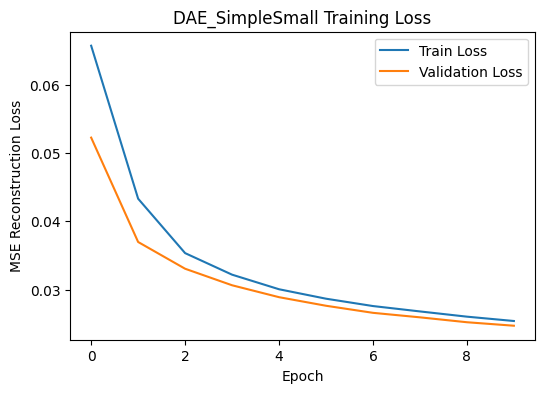

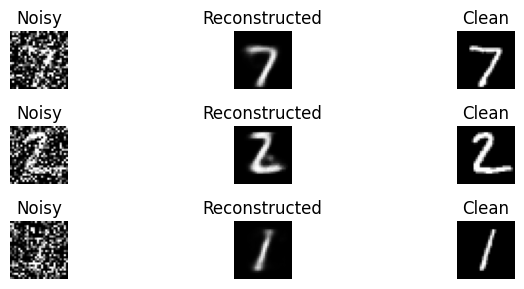

In [70]:


class DAE_SimpleSmall(nn.Module):
    """
    Simpler, smaller-capacity DAE for MNIST.
    Uses only Linear + ReLU + Sigmoid; no dropout/BN/skips.
    """
    def __init__(self, latent_dim=16):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256), nn.ReLU(),
            nn.Linear(256, 64),  nn.ReLU(),
            nn.Linear(64, latent_dim)      # linear bottleneck
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),  nn.ReLU(),
            nn.Linear(64, 256),         nn.ReLU(),
            nn.Linear(256, 784),
            nn.Sigmoid(),
            nn.Unflatten(1, (1, 28, 28))
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)
# --------------------------
# Training setup
# --------------------------
if torch.backends.mps.is_available() and torch.backends.mps.is_built():
    device = torch.device("mps")          # Apple GPU
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)
model = DAE_SimpleSmall(latent_dim=16).to(device)

criterion = nn.MSELoss()  # reconstruction loss (good for Gaussian noise)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Keep epochs logic as-is (adjust if you want)
num_epochs = 10

train_losses = []
val_losses = []

# --------------------------
# Training loop
# --------------------------
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for x_noisy, x_clean in train_loader:
        x_noisy, x_clean = x_noisy.to(device), x_clean.to(device)

        optimizer.zero_grad()
        outputs = model(x_noisy)
        loss = criterion(outputs, x_clean)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x_noisy.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    # Validation loop
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x_noisy, x_clean in test_loader:
            x_noisy, x_clean = x_noisy.to(device), x_clean.to(device)
            outputs = model(x_noisy)
            loss = criterion(outputs, x_clean)
            val_loss += loss.item() * x_noisy.size(0)

    val_loss /= len(test_loader.dataset)
    val_losses.append(val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}]  Train Loss: {epoch_loss:.4f}  Val Loss: {val_loss:.4f}")

    # Simple early stopping on plateau
    if epoch > 1 and abs(val_losses[-1] - val_losses[-2]) < 1e-5:
        print("Validation loss plateaued — stopping early.")
        break

# --------------------------
# Plot reconstruction loss
# --------------------------
plt.figure(figsize=(6,4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Reconstruction Loss")
plt.title("DAE_SimpleSmall Training Loss")
plt.legend()
plt.show()

# --------------------------
# Visualize reconstruction on test set
# --------------------------
model.eval()
x_noisy, x_clean = next(iter(test_loader))
x_noisy, x_clean = x_noisy.to(device), x_clean.to(device)
with torch.no_grad():
    recon = model(x_noisy)

plt.figure(figsize=(8,3))
for i in range(3):
    plt.subplot(3,3,3*i+1)
    plt.imshow(x_noisy[i][0].cpu(), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

    plt.subplot(3,3,3*i+2)
    plt.imshow(recon[i][0].cpu(), cmap="gray")
    plt.title("Reconstructed")
    plt.axis("off")

    plt.subplot(3,3,3*i+3)
    plt.imshow(x_clean[i][0].cpu(), cmap="gray")
    plt.title("Clean")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Iterating a Vanila DNAE
Now we will turn this DNAE into an iterative map by feeding it's output back in as input. To start we will do everything the same as far as setting up the De-noising auto encoder, but at the testing stage we will simply refeed the outputs back in as inputs. 

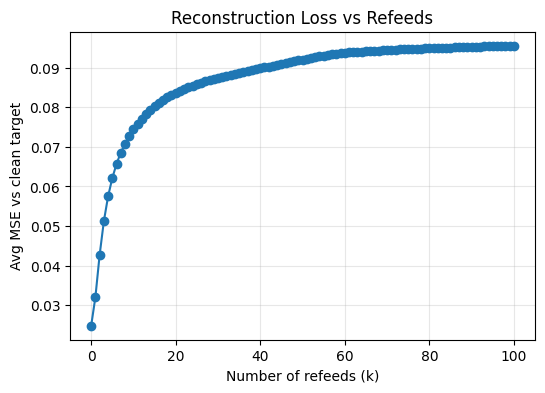

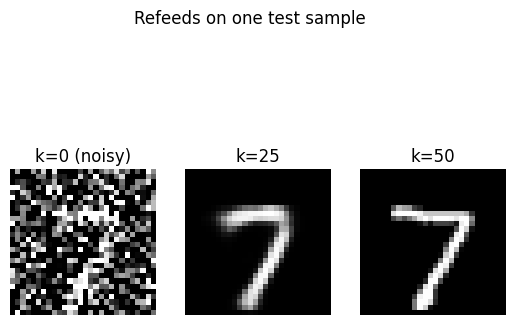

In [ ]:
import torch
import matplotlib.pyplot as plt

@torch.no_grad()
def evaluate_refeeds(model, loader, criterion, num_refeeds=5, device="cpu"):
    """
    Compute average reconstruction loss on the test set after k refeeds.
    k = 0 uses the noisy input once (no refed passes).
    k = 1 means model(model(x_noisy)), etc.
    Returns: list of length num_refeeds+1 with average loss at each k.
    """
    model.eval()
    losses_by_k = [0.0 for _ in range(num_refeeds + 1)]
    count = 0

    for x_noisy, x_clean in loader:
        x_noisy = x_noisy.to(device)
        x_clean = x_clean.to(device)

        # k = 0 (single pass on noisy input)
        xk = x_noisy.clone()
        for k in range(num_refeeds + 1):
            # one forward pass at current state
            out = model(xk)
            # measure loss against clean target
            loss = criterion(out, x_clean)
            losses_by_k[k] += loss.item() * x_noisy.size(0)

            # prepare next refeed input (model output fed back)
            xk = out

        count += x_noisy.size(0)#add the number of samples processed in this batch from the test_loader

    # average over dataset
    losses_by_k = [L / count for L in losses_by_k]
    return losses_by_k

# -------------------------------------------------------
# Run it and plot (assumes model, test_loader, device, criterion exist)
# -------------------------------------------------------
num_refeeds = 100  # adjust as you like
refeed_losses = evaluate_refeeds(model, test_loader, criterion, num_refeeds=num_refeeds, device=device)

plt.figure(figsize=(6,4))
plt.plot(range(num_refeeds + 1), refeed_losses, marker="o")
plt.xlabel("Number of refeeds (k)")
plt.ylabel("Avg MSE vs clean target")
plt.title("Reconstruction Loss vs Refeeds")
plt.grid(True, alpha=0.3)
plt.show()

@torch.no_grad()
def visualize_refeeds(model, loader, device="cpu", num_refeeds=5, idx=0):
    model.eval()
    x_noisy, x_clean = next(iter(loader))
    x_noisy, x_clean = x_noisy.to(device), x_clean.to(device)

    xk = x_noisy.clone()
    imgs = [x_noisy[idx:idx+1]]
    split_points = [round(i * num_refeeds / 4) for i in range(5)]
    split_points.insert(0, 1)
    for k in range(1, num_refeeds + 1):
        xk = model(xk)
        if k in split_points:
            imgs.append(xk[idx:idx+1])

    # Finally append the clean target for comparison
    imgs.append(x_clean[idx:idx+1])
    titles = [f"k={k}" for k in split_points]
    titles[0] = "k=0 (noisy)"
    titles.append("clean")

    for i, (img, title) in enumerate(zip(imgs, titles)):
        plt.subplot(1, len(imgs), i + 1)
        plt.imshow(img[0,0].cpu(), cmap="gray")
        plt.title(title)
        plt.axis("off")
    plt.suptitle("Refeeds on one test sample")
    plt.show()

# Example:
visualize_refeeds(model, test_loader, device=device, num_refeeds=num_refeeds, idx=0)

Now we see if showing a random number of recurssive iterations during training will help.

Epoch [1/10]  Train 0.0714  Val(mean) 0.0676  | k=1:0.0676  k=2:0.0675  k=3:0.0676  k=5:0.0676  k=10:0.0676
Epoch [2/10]  Train 0.0674  Val(mean) 0.0649  | k=1:0.0642  k=2:0.0651  k=3:0.0650  k=5:0.0651  k=10:0.0652
Epoch [3/10]  Train 0.0653  Val(mean) 0.0643  | k=1:0.0639  k=2:0.0641  k=3:0.0643  k=5:0.0646  k=10:0.0647
Epoch [4/10]  Train 0.0635  Val(mean) 0.0621  | k=1:0.0616  k=2:0.0619  k=3:0.0622  k=5:0.0624  k=10:0.0625
Epoch [5/10]  Train 0.0661  Val(mean) 0.0630  | k=1:0.0623  k=2:0.0627  k=3:0.0628  k=5:0.0632  k=10:0.0639
Epoch [6/10]  Train 0.0619  Val(mean) 0.0611  | k=1:0.0607  k=2:0.0607  k=3:0.0608  k=5:0.0611  k=10:0.0619
Epoch [7/10]  Train 0.0608  Val(mean) 0.0601  | k=1:0.0596  k=2:0.0598  k=3:0.0600  k=5:0.0602  k=10:0.0607
Epoch [8/10]  Train 0.0610  Val(mean) 0.0601  | k=1:0.0594  k=2:0.0598  k=3:0.0600  k=5:0.0603  k=10:0.0608
Epoch [9/10]  Train 0.0615  Val(mean) 0.0608  | k=1:0.0595  k=2:0.0603  k=3:0.0609  k=5:0.0613  k=10:0.0620
Epoch [10/10]  Train 0.0602 

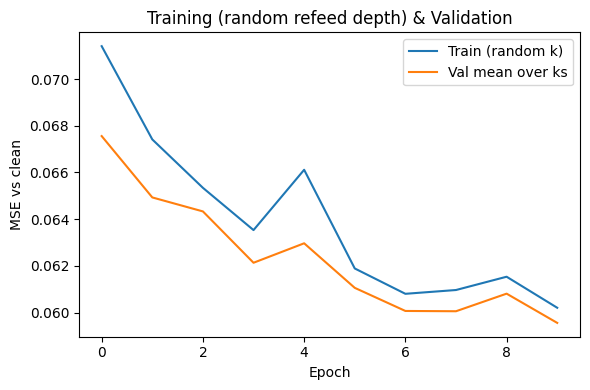

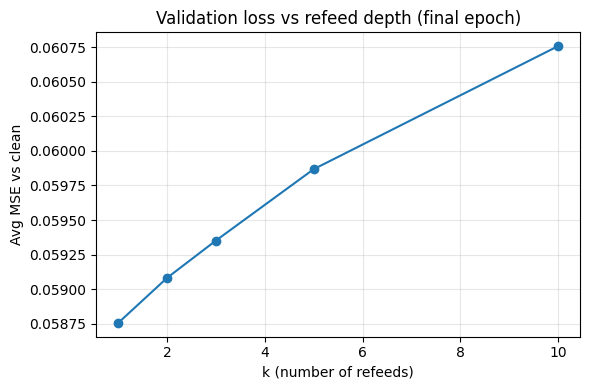

In [66]:
# Fresh model/optim/criterion
model = DAE_SimpleSmall(latent_dim=16).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# -------------------------------------------------
# Helper: apply model k times (refeeding outputs)
# -------------------------------------------------
def apply_k_times(model, x, k: int):
    y = x
    for _ in range(k):
        y = model(y)
    return y

# -------------------------------------------------
# Training loop with random k per batch
# -------------------------------------------------
num_epochs = 10
Kmin, Kmax = 1, 10

train_losses = []
val_losses_mean = []
val_losses_by_k_hist = []  # list of dicts per epoch (k -> loss)

for epoch in range(num_epochs):
    model.train()
    running = 0.0

    for x_noisy, x_clean in train_loader:
        x_noisy, x_clean = x_noisy.to(device), x_clean.to(device)

        # sample a random number of refeeds for this batch
        k = random.randint(Kmin, Kmax)

        optimizer.zero_grad()
        yk = apply_k_times(model, x_noisy, k)  # no detach → backprop through all k steps
        loss = criterion(yk, x_clean)
        loss.backward()
        optimizer.step()

        running += loss.item() * x_noisy.size(0)

    epoch_train = running / len(train_loader.dataset)
    train_losses.append(epoch_train)

    # --------------------------
    # Validation: evaluate fixed ks and average
    # --------------------------
    model.eval()
    ks_eval = [1, 2, 3, 5, 10]  # feel free to change
    loss_sums = {k: 0.0 for k in ks_eval}
    count = 0

    with torch.no_grad():
        for x_noisy, x_clean in test_loader:
            x_noisy, x_clean = x_noisy.to(device), x_clean.to(device)
            bsz = x_noisy.size(0)
            for k in ks_eval:
                yk = apply_k_times(model, x_noisy, k)
                loss_sums[k] += criterion(yk, x_clean).item() * bsz
            count += bsz

    loss_avgs = {k: loss_sums[k] / count for k in ks_eval}
    val_losses_by_k_hist.append(loss_avgs)
    # mean across the chosen ks for a single scalar to track
    val_mean = sum(loss_avgs.values()) / len(loss_avgs)
    val_losses_mean.append(val_mean)

    ks_str = "  ".join([f"k={k}:{loss_avgs[k]:.4f}" for k in ks_eval])
    print(f"Epoch [{epoch+1}/{num_epochs}]  Train {epoch_train:.4f}  Val(mean) {val_mean:.4f}  | {ks_str}")

# -------------------------------------------------
# Plot training loss and mean validation loss
# -------------------------------------------------
plt.figure(figsize=(6,4))
plt.plot(train_losses, label="Train (random k)")
plt.plot(val_losses_mean, label="Val mean over ks")
plt.xlabel("Epoch")
plt.ylabel("MSE vs clean")
plt.title("Training (random refeed depth) & Validation")
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------------------------------
# Plot validation loss vs k for final epoch
# -------------------------------------------------
final_k_losses = val_losses_by_k_hist[-1]
plt.figure(figsize=(6,4))
plt.plot(list(final_k_losses.keys()),
         [final_k_losses[k] for k in final_k_losses.keys()],
         marker="o")
plt.xlabel("k (number of refeeds)")
plt.ylabel("Avg MSE vs clean")
plt.title("Validation loss vs refeed depth (final epoch)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Diagnosing attractors

## Formal Definition of an attractor for a discrete time dynamical system

For discrete dymamical system. 

$$x_{k+1} = f(x_{k}) \qquad x_{k} \epsilon \mathbb{R}^{n}$$

an attractor $A \subset \mathbb{R}^n$ is a set satisfying
1. Invarience: $f(A) = A$ if you are at the point of the attractor you stay there.
2. Attraction: There exists a basin of attraction $B(A)$ such that: 
$$\forall x_0 \epsilon B(A), \lim{k \to \infty} dist(x_k, A) = 0$$ in otherwords trajectories close the the attractor converge to it.$$
3. Minimality: There's no smaller closed invariant set that attracts the same basin.

Attractors can be:
- Fixed points: $X^* = f(x^*)$
- Limit Cycles: periodic orbits, $f^{p}(x) = x$
- chaotic attractors: invariant, bounded, fractal-like sets with positive Lyapunov exponets

## detecting attractors

(A) Fixed Point / Cycle Tests

1. Fixed Points: Solve $F(x) - x = 0$
2. Limit Cycles: Detect repeating states $\| x_{k+p} - x_k\| < \epsilon$ for some tolerance $\epsilon$ and some period $p > 1$ 




In [ ]:
import torch
from dataclasses import dataclass
from typing import Callable, Optional, Tuple

def detect_fixed_point(
    traj: torch.Tensor,
    eps: float = 1e-4,
    norm_dim: Optional[Tuple[int, ...]] = None,
):
    """
    Detect the earliest approximate fixed point along a trajectory.

    Args:
        traj: Tensor (T, *shape), a sequence x_0, x_1, ..., x_{T-1}.
        eps: (epsilon) small positive Threshold for ||x_{t+1} - x_t|| < eps.
        norm_dim: Which dims to reduce over when computing norms.
                  By default reduces over all but the time dimension.

    Returns:
        t: The earliest index t (0-based) such that ||x_{t+1}-x_t|| < eps,
           or None if not found.

    Notes:
        - This numerically tests f(x_t) ≈ x_t.
        - A fixed point is a candidate attractor (stability assessed separately).
    """
    if norm_dim is None:
        norm_dim = tuple(range(1, traj.dim()))
    diffs = (traj[1:] - traj[:-1]).norm(dim=norm_dim)
    idx = (diffs < eps).nonzero(as_tuple=False)
    return int(idx[0].item()) if idx.numel() > 0 else None



def detect_cycle(
    traj: torch.Tensor,
    max_period: int = 10,
    eps: float = 1e-3,
    norm_dim: Optional[Tuple[int, ...]] = None,
) -> Tuple[Optional[int], Optional[int]]:
    """
    Detect a short limit cycle (period 2..max_period) along the trajectory.

    Args:
        traj: Tensor (T, *shape), trajectory x_0..x_{T-1}.
        max_period: Maximum period p to test.
        eps: Threshold for ||x_t - x_{t-p}|| < eps.
        norm_dim: Dims to reduce when computing norms (default: all but time).

    Returns:
        (start_t, period): Earliest start index and period p, or (None, None).

    Notes:
        - For long/complex cycles, increase `max_period` or analyze the monodromy separately.
    """
    if norm_dim is None:
        norm_dim = tuple(range(1, traj.dim()))
    T = traj.size(0)
    for p in range(2, max_period + 1):
        for t in range(p, T):
            if (traj[t] - traj[t - p]).norm(dim=norm_dim) < eps:
                return t - p, p
    return None, None



(B) Local Stability (Jacobian/Linearization)

at any fixed point $x^*$: 

1. Compute the Jacobian $J = Df(x^*)$
2. Find its eigenvalues $\lambda_{i}$

- Stable(attracting): $|\lambda_{i} < 1$ for all $i$
- Unstable (repelling): any $|\lambda_{i}| > 1$
- Marginal: some $|\lambda_{i}| = 1$

In [ ]:
def jvp(f: Callable[[torch.Tensor], torch.Tensor], x: torch.Tensor, v: torch.Tensor) -> torch.Tensor:
    """
    Compute J_f(x) @ v (same shape as x) using autograd.
    x, v have shape (1, D). Returns (1, D).
    """
    x = x.detach().requires_grad_(True)
    y = f(x)
    assert y.shape == x.shape, "f must be R^D -> R^D (pointwise denoiser)."
    dot = (y * v).sum()
    (grad_x,) = torch.autograd.grad(dot, x, retain_graph=True, create_graph=False)
    return grad_x


def vjp(f: Callable[[torch.Tensor], torch.Tensor], x: torch.Tensor, u: torch.Tensor) -> torch.Tensor:
    """
    Compute J_f(x)^T @ u (same shape as x) using autograd.
    x, u have shape (1, D). Returns (1, D).
    """
    x = x.detach().requires_grad_(True)
    y = f(x)
    (grad_x,) = torch.autograd.grad(outputs=y, inputs=x, grad_outputs=u, retain_graph=True, create_graph=False)
    return grad_x


def spectral_norm_of_jacobian(
    f: Callable[[torch.Tensor], torch.Tensor],
    x_star: torch.Tensor,
    iters: int = 50,
    device: str = "cpu",
) -> float:
    """
    Estimate ||J_f(x*)||_2 (largest singular value) via power iteration on J^T J, without
    materializing J. If < 1, f is locally a contraction at x* (sufficient condition).
    
    """
    with torch.no_grad():
        x = x_star.view(1, -1).to(device)

    u = torch.randn_like(x)
    u = u / (u.norm() + 1e-12)

    for _ in range(iters):
        # v = (J^T J) u  ≈  J^T (J u)
        w = jvp(f, x, u)       # w = J u
        v = vjp(f, x, w)       # v = J^T w
        v_norm = v.norm() + 1e-12
        u = v / v_norm

    # Rayleigh quotient: ||J u||_2 is the singular value estimate
    Ju = jvp(f, x, u)
    return float(Ju.norm().item())
